# <span style="color:rgb(213,80,0)">BattMo Tutorial</span>

This tutorial explains how to setup and run a simulation in BattMo

First clear variables stored in memory and close all figures


In [1]:
clear;
close all;


## Specifying the physical model

In this tutorial we will simulate a lithium\-ion battery consisting of a negative electrode, a positive electrode and an electrolyte. **BattMo** comes with some pre\-defined models which can be loaded from JSON files. Here we will load the basic lithium\-ion model JSON file which comes with Battmo. The function `parseBattmoJson` parses files and a file path can be given from the battmo root directory.


In [2]:
fname = fullfile('ParameterData','BatteryCellParameters',...
                 'LithiumIonBatteryCell','lithium_ion_battery_nmc_graphite.json');
jsonstruct = parseBattmoJson(fname);


The parseBattmoJson function parses the JSON input and creates a matlab structure containing the same fields as the JSON input. This structure can be changed to setup the model in the way that we want.

In this instance we will exclude temperature effects by setting use\_thermal to false.


In [3]:
jsonstruct.use_thermal = false;


We will also not use current collectors in this example:


In [4]:
jsonstruct.include_current_collectors = false;


The structure created in the jsonstruct follows the same hierarchy as the fields in the JSON input file. These can be referenced by name in the jsonstruct. To make life easier for ourselves we define some shorthand names for various parts of the structure.


In [5]:
ne      = 'NegativeElectrode';
pe      = 'PositiveElectrode';
elyte   = 'Electrolyte';
thermal = 'ThermalModel';
co      = 'Coating';
am      = 'ActiveMaterial';
itf     = 'Interface';
sd      = 'SolidDiffusion';
ctrl    = 'Control';
cc      = 'CurrentCollector';


It is also possible to update the properties of this inputparams in a similar way to updating the jsonstruct. Here we set the discretisation level for the diffusion model.


In [6]:
jsonstruct.(ne).(co).(am).(sd).N = 5;
jsonstruct.(pe).(co).(am).(sd).N = 5;


We can also change how the battery is operated, for example setting the cut off voltage.


In [7]:
jsonstruct.(ctrl).lowerCutoffVoltage = 2.5;


## Setting up the geometry

Here, we setup the 1D computational grid that will be used for the simulation.


In [8]:
filename = fullfile('Examples', 'JsonDataFiles', 'geometry1d.json');
jsonstruct_geometry = parseBattmoJson(filename);


We can use the function `flattenStruct` which flattens the structure so that we can visualize all the fields at once


In [9]:
flattenStruct(jsonstruct_geometry);


We can change the thickness of the coating of the negative electrode


In [10]:
jsonstruct_geometry.(ne).(co).thickness = 6e-05;


We merge the jsonstuct that contains the geometrical property to the main one using the function `mergeStructs`


In [11]:
jsonstruct = mergeStructs({jsonstruct, jsonstruct_geometry});


We can now visualise the whole input parameter set using `flattenStruct`. Note that some of the parameters will not be used because of our model choice, for example the thermal parameters or the parameters for the current collectors.


In [12]:
flattenStruct(jsonstruct);


## Run the simulation

We run the simulation by passing the json input structure to the function `runBatteryJson`


In [13]:
output = runBatteryJson(jsonstruct);


Let us look at the returned output


In [14]:
disp(output)

          model: [1x1 GenericBattery]
    inputparams: [1x1 BatteryInputParams]
       simsetup: [1x1 SimulationSetup]
     jsonstruct: [1x1 struct]
           time: [96x1 double]
              E: [96x1 double]
              I: [96x1 double]
       globvars: {96x1 cell}
         states: {96x1 cell}


We have in particular:

- `model` which contains the model object. The model contains basically all the functions that describes the system and the recipy on how to assemble the equations. As such, it contains among other thing all the data that was sent from the json file.
- `initstate` is the initial state, which is often the equilibrium state of the battery at a given state of charge. This is the case here
- `states` contains the results of the simulation. It is a cell array where each cell contains the state of the system at a given time step.
- `time`, `E` and `I` which are the time, voltage and current values, respectively. They are conveniently added to the output but they could be recover from the `states`

## Plotting the results

To get the results we use the matlab cellfun function to extract the values Control.E, Control.I and time from each timestep (cell in the cell array) in states. We can then plot the vectors.

We set thicker line widths and larger font sizes



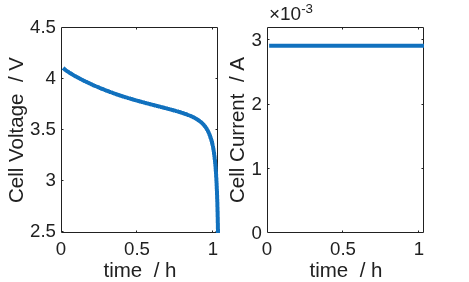

In [15]:
set(0, 'defaultLineLineWidth', 3);
set(0, 'defaultAxesFontSize', 16);
set(0, 'defaultTextFontSize', 18);


E    = output.E;
I    = output.I;
time = output.time;


figure()


subplot(1,2,1)
plot(time/hour, E)
xlabel('time  / h')
ylabel('Cell Voltage  / V')


subplot(1,2,2)
plot(time/hour, I)
ylim([0, 1.1*max(I)]);
xlabel('time  / h')
ylabel('Cell Current  / A')


## Plotting the OCP curves against state of charge

We can inspect the model object to find out which parameters are being used. For instance the information we need to plot the OCP curves for the positive and negative electrodes can be found in the interface sub\-model of each electrode.


In [16]:
T = 298.15;
eldes = {ne, pe};


figure
hold on


model = output.model;


for ielde = 1:numel(eldes)


    elde = eldes{ielde};


In the interface submodel of the active material in the coating, we have the half\-ocp function. we retrieve the interface sub\-model of the given electrode.


In [17]:
    interface_model = model.(elde).(co).(am).(itf);


    theta100 = interface_model.guestStoichiometry100;   % Guest stoichiometry at 100% charge
    theta0   = interface_model.guestStoichiometry0;     % Guest stoichiometry at 0% charge
    cmax     = interface_model.saturationConcentration; % Saturation concentration


We set up a vector of concentration that spans the whole range of concentrations.


In [18]:
    soc   = linspace(0, 1);
    theta = soc*theta100 + (1 - soc)*theta0;
    c     = theta.*cmax;

    % The function |computeOCPFunc| returns the OCP function for the given stoichiometry

    OCP = interface_model.computeOCP(c./cmax);


we plot the OCP curve for the given electrode as a function of the state of charge



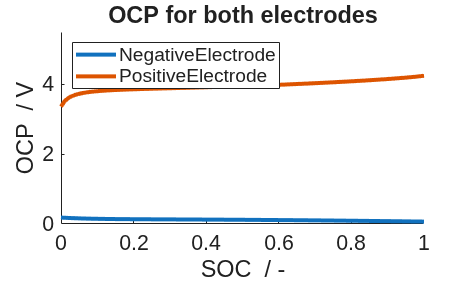

In [19]:
    plot(soc, OCP)
end


xlabel('SOC  / -')
ylabel('OCP  / V')
title('OCP for both electrodes');
ylim([0, 5.5])
legend(eldes, 'location', 'nw');

In [20]:


%{
Copyright 2021-2024 SINTEF Industry, Sustainable Energy Technology
and SINTEF Digital, Mathematics & Cybernetics.


This file is part of The Battery Modeling Toolbox BattMo


BattMo is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.


BattMo is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.


You should have received a copy of the GNU General Public License
along with BattMo.  If not, see <http://www.gnu.org/licenses/>.
%}